# News Classifier — BBC Articles

Clasificador de noticias usando Transformers sobre el dataset BBC Articles.

## 1. Instalación de librerías

In [1]:
%pip install -q --upgrade pip
%pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn transformers datasets accelerate nltk
%pip install -q --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu128

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 2. Importar librerías

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from datasets import Dataset as HFDataset

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('Python:', os.sys.executable)
print('PyTorch:', torch.__version__)
print('CUDA build:', torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA no esta disponible en este kernel. '
        'Ejecuta la celda de instalacion, reinicia el kernel y vuelve a correr desde el inicio.'
    )

device = torch.device('cuda:0')
torch.cuda.set_device(device)
print(f'Usando device: {device} - {torch.cuda.get_device_name(0)}')

c:\Users\USUARIO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: c:\Users\USUARIO\AppData\Local\Python\pythoncore-3.14-64\python.exe
PyTorch: 2.11.0+cu128
CUDA build: 12.8
Usando device: cuda:0 - NVIDIA GeForce RTX 5060


## 3. Descargar dataset desde Kaggle

In [3]:
import shutil

# Descarga al cache global de kagglehub
path = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")
print('Cache:', path)

# Copia los CSVs a una carpeta data/ dentro del proyecto (para commitear)
PROJECT_DIR = os.getcwd()
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.csv'):
            src = os.path.join(root, f)
            dst = os.path.join(DATA_DIR, f)
            if not os.path.exists(dst):
                shutil.copy(src, dst)
            print('->', dst)

Cache: C:\Users\USUARIO\.cache\kagglehub\datasets\jacopoferretti\bbc-articles-dataset\versions\16
-> c:\Users\USUARIO\Desktop\transformers'bbc\DL-TRANSFORMERS\data\bbc_news_text_complexity_summarization.csv
-> c:\Users\USUARIO\Desktop\transformers'bbc\DL-TRANSFORMERS\data\bbc_text_cls.csv
-> c:\Users\USUARIO\Desktop\transformers'bbc\DL-TRANSFORMERS\data\bbc-news-data.csv


In [4]:
# Carga desde la carpeta data/ del proyecto
csv_files = sorted([os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print('CSVs en data/:', csv_files)

# Usamos bbc_text_cls.csv que es el más limpio para clasificación (text + labels)
df = pd.read_csv(os.path.join(DATA_DIR, 'bbc_text_cls.csv'))
df.head()

CSVs en data/: ["c:\\Users\\USUARIO\\Desktop\\transformers'bbc\\DL-TRANSFORMERS\\data\\bbc-news-data.csv", "c:\\Users\\USUARIO\\Desktop\\transformers'bbc\\DL-TRANSFORMERS\\data\\bbc_news_text_complexity_summarization.csv", "c:\\Users\\USUARIO\\Desktop\\transformers'bbc\\DL-TRANSFORMERS\\data\\bbc_text_cls.csv"]


,text,labels
0,Ad sales boost Time Warner profit\r\n\r\nQuart...,business
1,Dollar gains on Greenspan speech\r\n\r\nThe do...,business
2,Yukos unit buyer faces loan claim\r\n\r\nThe o...,business
3,High fuel prices hit BA's profits\r\n\r\nBriti...,business
4,Pernod takeover talk lifts Domecq\r\n\r\nShare...,business


## 4. Preprocesamiento

Como vamos a usar Transformers (BERT/DistilBERT), la limpieza es **mínima**: el tokenizer del modelo se encarga del resto. NO hacemos lowercasing, NO removemos stopwords, NO lematizamos.

### 4.1 EDA básico

In [5]:
print('Shape:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nNulos por columna:')
print(df.isnull().sum())
print('\nDuplicados:', df.duplicated().sum())
print('\nDistribución de clases:')
print(df['labels'].value_counts())

Shape: (2225, 2)

Columnas: ['text', 'labels']

Nulos por columna:
text      0
labels    0
dtype: int64

Duplicados: 98

Distribución de clases:
labels
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


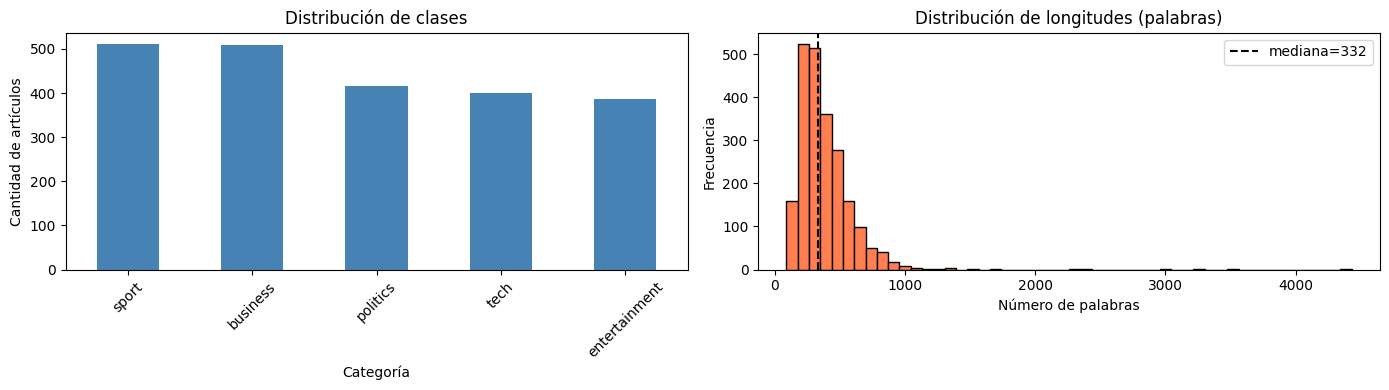

Longitud (palabras) — min: 89, max: 4432, media: 384, p95: 729


In [6]:
# Distribución visual de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['labels'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de clases')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Cantidad de artículos')
axes[0].tick_params(axis='x', rotation=45)

# Distribución de longitudes (en palabras) para definir max_length del tokenizer
df['n_words'] = df['text'].str.split().str.len()
axes[1].hist(df['n_words'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Distribución de longitudes (palabras)')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df['n_words'].median(), color='black', linestyle='--', label=f"mediana={df['n_words'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Longitud (palabras) — min: {df['n_words'].min()}, max: {df['n_words'].max()}, "
      f"media: {df['n_words'].mean():.0f}, p95: {df['n_words'].quantile(0.95):.0f}")

### 4.2 Limpieza mínima

Solo lo necesario: drop nulos/duplicados, normalizar whitespace y remover URLs/HTML si los hay. **Mantenemos** mayúsculas, puntuación y stopwords.

In [7]:
def clean_text(text: str) -> str:
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'<.*?>', ' ', text)              # HTML
    text = re.sub(r'\s+', ' ', text)                # whitespace múltiple
    return text.strip()

# Aplicar limpieza
df = df.dropna(subset=['text', 'labels']).copy()
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df['text'] = df['text'].astype(str).apply(clean_text)

# Eliminar textos vacíos tras limpieza
df = df[df['text'].str.len() > 0].reset_index(drop=True)

print('Shape después de limpieza:', df.shape)
df.head(2)

Shape después de limpieza: (2127, 3)


,text,labels,n_words
0,Ad sales boost Time Warner profit Quarterly pr...,business,421
1,Dollar gains on Greenspan speech The dollar ha...,business,384


### 4.3 Encoding de labels

In [8]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['labels'])

# Mapeos id <-> nombre (los necesita el modelo)
id2label = {i: c for i, c in enumerate(le.classes_)}
label2id = {c: i for i, c in enumerate(le.classes_)}

print('Clases:', list(le.classes_))
print('id2label:', id2label)
print('Num labels:', len(le.classes_))

Clases: ['business', 'entertainment', 'politics', 'sport', 'tech']
id2label: {0: 'business', 1: 'entertainment', 2: 'politics', 3: 'sport', 4: 'tech'}
Num labels: 5


### 4.4 Split estratificado: train / val / test (70/15/15)

In [9]:
SEED = 42

# Primero separamos test (15%)
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=SEED
)

# Luego separamos val del resto (15% del total ≈ 17.6% del 85% restante)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15/0.85, stratify=train_val_df['label'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('\nDistribución por split:')
print(pd.DataFrame({
    'train': train_df['labels'].value_counts(normalize=True).round(3),
    'val':   val_df['labels'].value_counts(normalize=True).round(3),
    'test':  test_df['labels'].value_counts(normalize=True).round(3),
}))

Train: 1488 | Val: 319 | Test: 320

Distribución por split:
               train    val   test
labels                            
sport          0.237  0.238  0.238
business       0.237  0.235  0.238
politics       0.190  0.188  0.191
entertainment  0.173  0.176  0.172
tech           0.163  0.163  0.162


## 5. Tokenización con el modelo

_(siguiente paso: cargar `AutoTokenizer` del modelo elegido — DistilBERT recomendado por velocidad — y tokenizar `train_df`, `val_df`, `test_df` con el `max_length` que decidas según la distribución de longitudes de la sección 4.1)_